# Solution Demo: NER + Image Classification Pipeline

This notebook demonstrates the complete solution for animal detection combining:
- Named Entity Recognition (NER) for text analysis
- Image Classification using ResNet50 transfer learning

## 1. Setup and Imports

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# Add parent directory to path
sys.path.append('..')

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Load Models and Functions

In [2]:
# Import inference functions
sys.path.insert(0, '../cnn')
from inference_image import load_model, load_dataset_stats, get_transform, predict_image, load_and_preprocess_image

# Import NER inference
sys.path.insert(0, '../ner')
from inference_ner import load_model as load_ner_model, predict_entities

print("Functions imported successfully")

Functions imported successfully


## 3. Test Image Classification Model

In [3]:
# Load image classification model
MODEL_PATH = "../cnn/resnet_model.pth"

if os.path.exists(MODEL_PATH):
    img_model = load_model(MODEL_PATH, num_classes=10, device=device)
    mean, std, class_names = load_dataset_stats(MODEL_PATH)
    transform = get_transform(mean, std)
    print(f"Model loaded successfully")
    print(f"Classes: {class_names}")
else:
    print(f"Model not found at {MODEL_PATH}")
    print("Please train the model first using: python ../cnn/training.py --data_dir ../raw-img")

Model loaded from ../cnn/resnet_model.pth
Model loaded successfully
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


## 4. Test Cases: Image Classification

### 4.1.1. Basic Test - Dog Image

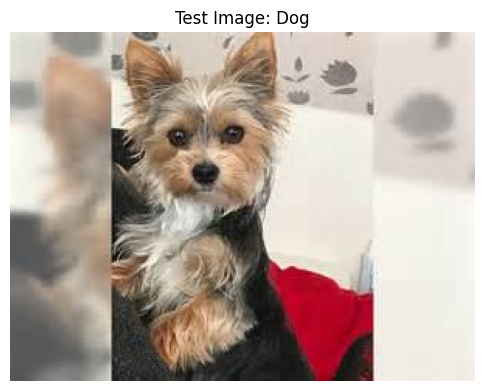


Prediction: dog
Confidence: 99.99%

Top 3 probabilities:
  dog: 99.99%
  cat: 0.01%
  spider: 0.00%


In [20]:
# Test with dog image
test_image_path = "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"

if os.path.exists(test_image_path) and os.path.exists(MODEL_PATH):
    # Display image
    img = Image.open(test_image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Test Image: Dog")
    plt.show()
    
    # Predict
    image_tensor = load_and_preprocess_image(test_image_path, transform)
    result = predict_image(img_model, image_tensor, class_names, device)
    
    print(f"\nPrediction: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print("\nTop 3 probabilities:")
    for idx, (cls, prob) in enumerate(result['all_probabilities'].items()):
        if idx >= 3:
            break
        print(f"  {cls}: {prob:.2%}")
else:
    print("Test image or model not found")

### 4.1.2. Basic Test - Cat Image (Incorrect classification)

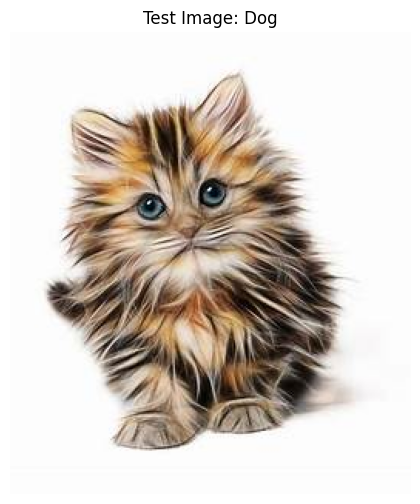


Prediction: dog
Confidence: 86.78%

Top 3 probabilities:
  dog: 86.78%
  cat: 13.05%
  chicken: 0.10%


In [ ]:
# Test with cat image
test_image_path = "../raw-img/gatto/5.jpeg"

if os.path.exists(test_image_path) and os.path.exists(MODEL_PATH):
    # Display image
    img = Image.open(test_image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Test Image: Dog")
    plt.show()
    
    # Predict
    image_tensor = load_and_preprocess_image(test_image_path, transform)
    result = predict_image(img_model, image_tensor, class_names, device)
    
    print(f"\nPrediction: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print("\nTop 3 probabilities:")
    for idx, (cls, prob) in enumerate(result['all_probabilities'].items()):
        if idx >= 3:
            break
        print(f"  {cls}: {prob:.2%}")
else:
    print("Test image or model not found")

### 4.2. Model Evaluation on Dataset

Comprehensive evaluation with confusion matrix and prediction analysis

Evaluating model on dataset sample...
Evaluating on 500 images...

Overall Accuracy: 97.80%
Correct predictions: 489/500


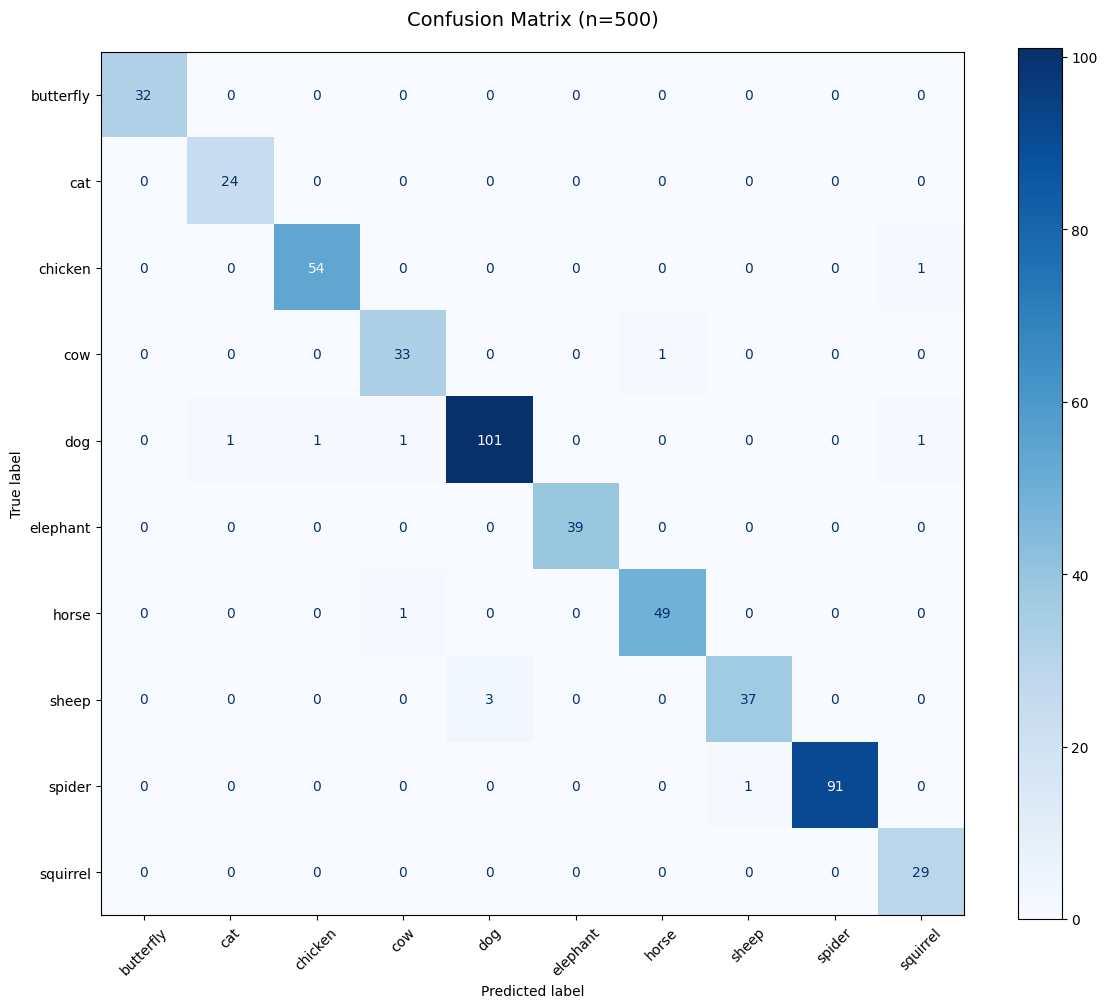


Classification Report:
              precision    recall  f1-score   support

   butterfly       1.00      1.00      1.00        32
         cat       0.96      1.00      0.98        24
     chicken       0.98      0.98      0.98        55
         cow       0.94      0.97      0.96        34
         dog       0.97      0.96      0.97       105
    elephant       1.00      1.00      1.00        39
       horse       0.98      0.98      0.98        50
       sheep       0.97      0.93      0.95        40
      spider       1.00      0.99      0.99        92
    squirrel       0.94      1.00      0.97        29

    accuracy                           0.98       500
   macro avg       0.97      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



In [9]:
# Evaluate model on dataset sample
import random
from torchvision import datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from inference_image import ITALIAN_TO_ENGLISH

if os.path.exists(MODEL_PATH):
    print("Evaluating model on dataset sample...")
    
    # Load dataset
    data_dir = "../raw-img"
    simple_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    full_dataset = datasets.ImageFolder(data_dir, transform=simple_transform)
    
    # Sample subset for evaluation (to speed up, adjust as needed)
    sample_size = min(500, len(full_dataset))  # Evaluate on 500 random images
    random.seed(42)
    sample_indices = random.sample(range(len(full_dataset)), sample_size)
    
    print(f"Evaluating on {sample_size} images...")
    
    # Collect predictions
    y_true = []
    y_pred = []
    predictions_details = []
    
    for idx in sample_indices:
        img_path, label_idx = full_dataset.samples[idx]
        
        # True label
        true_italian = full_dataset.classes[label_idx]
        true_english = ITALIAN_TO_ENGLISH.get(true_italian, true_italian)
        
        # Predict
        image_tensor = load_and_preprocess_image(img_path, transform)
        result = predict_image(img_model, image_tensor, class_names, device)
        pred_english = result['predicted_class']
        
        y_true.append(true_english)
        y_pred.append(pred_english)
        
        # Store details for later analysis
        predictions_details.append({
            'path': img_path,
            'true': true_english,
            'pred': pred_english,
            'confidence': result['confidence'],
            'correct': true_english.lower() == pred_english.lower()
        })
    
    # Calculate accuracy
    accuracy = sum(1 for p in predictions_details if p['correct']) / len(predictions_details)
    print(f"\nOverall Accuracy: {accuracy:.2%}")
    print(f"Correct predictions: {sum(1 for p in predictions_details if p['correct'])}/{len(predictions_details)}")

    # Create confusion matrix
    labels = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix (n={sample_size})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print("=" * 70)
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    
else:
    print("Model not found")

### 4.3. Prediction Examples Analysis

Examples of correct and incorrect predictions

Examples of CORRECT predictions with high confidence:


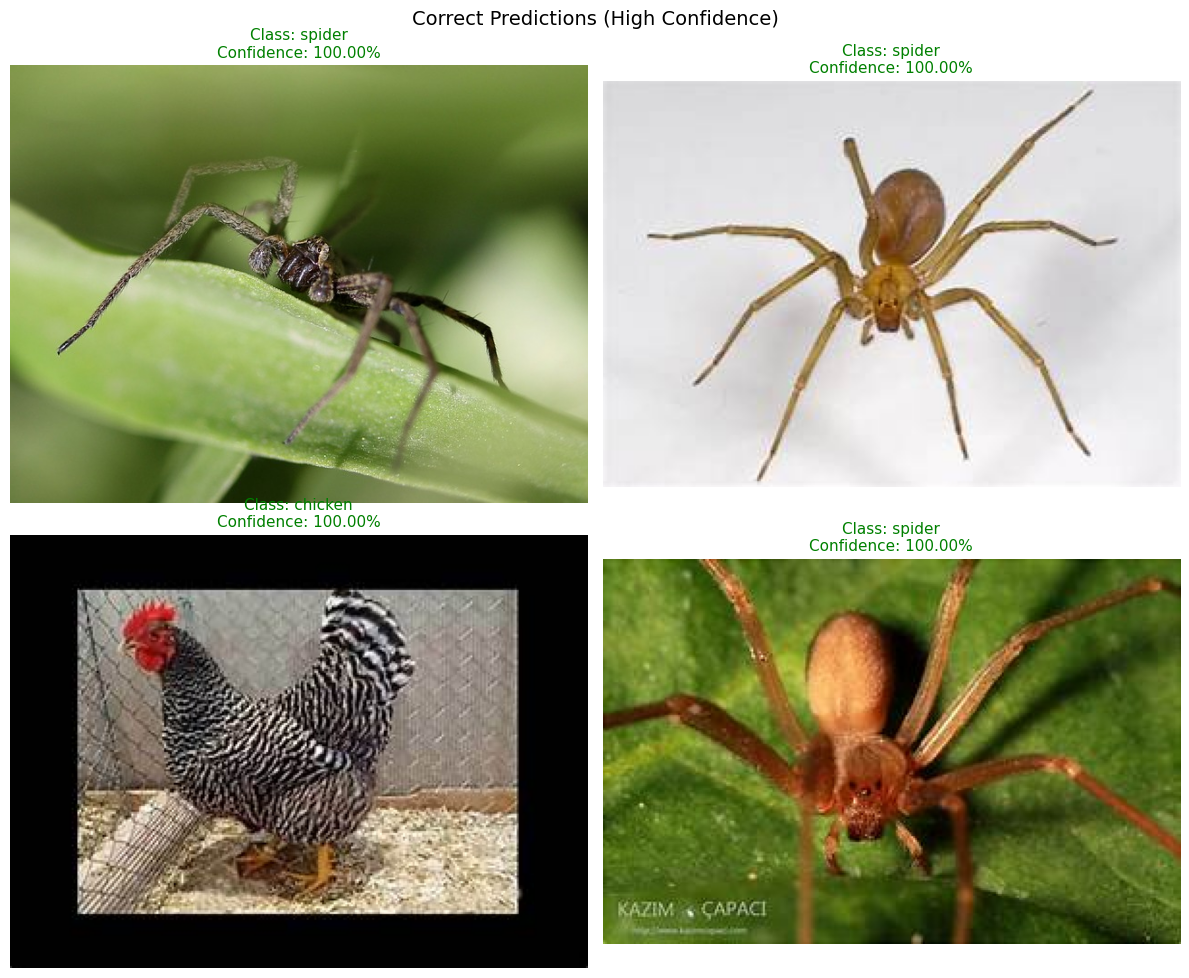


Average confidence for correct predictions: 98.22%
Total correct: 489


In [10]:
# Show examples of correct predictions (high confidence)
if os.path.exists(MODEL_PATH) and 'predictions_details' in locals():
    print("Examples of CORRECT predictions with high confidence:")
    print("=" * 70)
    
    # Get correct predictions sorted by confidence
    correct_preds = [p for p in predictions_details if p['correct']]
    correct_preds_sorted = sorted(correct_preds, key=lambda x: x['confidence'], reverse=True)
    
    # Show top 4
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(min(4, len(correct_preds_sorted))):
        pred = correct_preds_sorted[idx]
        
        img = Image.open(pred['path'])
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(
            f"Class: {pred['true']}\nConfidence: {pred['confidence']:.2%}",
            fontsize=11,
            color='green'
        )
    
    plt.suptitle("Correct Predictions (High Confidence)", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Print stats
    avg_conf_correct = sum(p['confidence'] for p in correct_preds) / len(correct_preds)
    print(f"\nAverage confidence for correct predictions: {avg_conf_correct:.2%}")
    print(f"Total correct: {len(correct_preds)}")
else:
    print("Run evaluation first")


Examples of INCORRECT predictions:


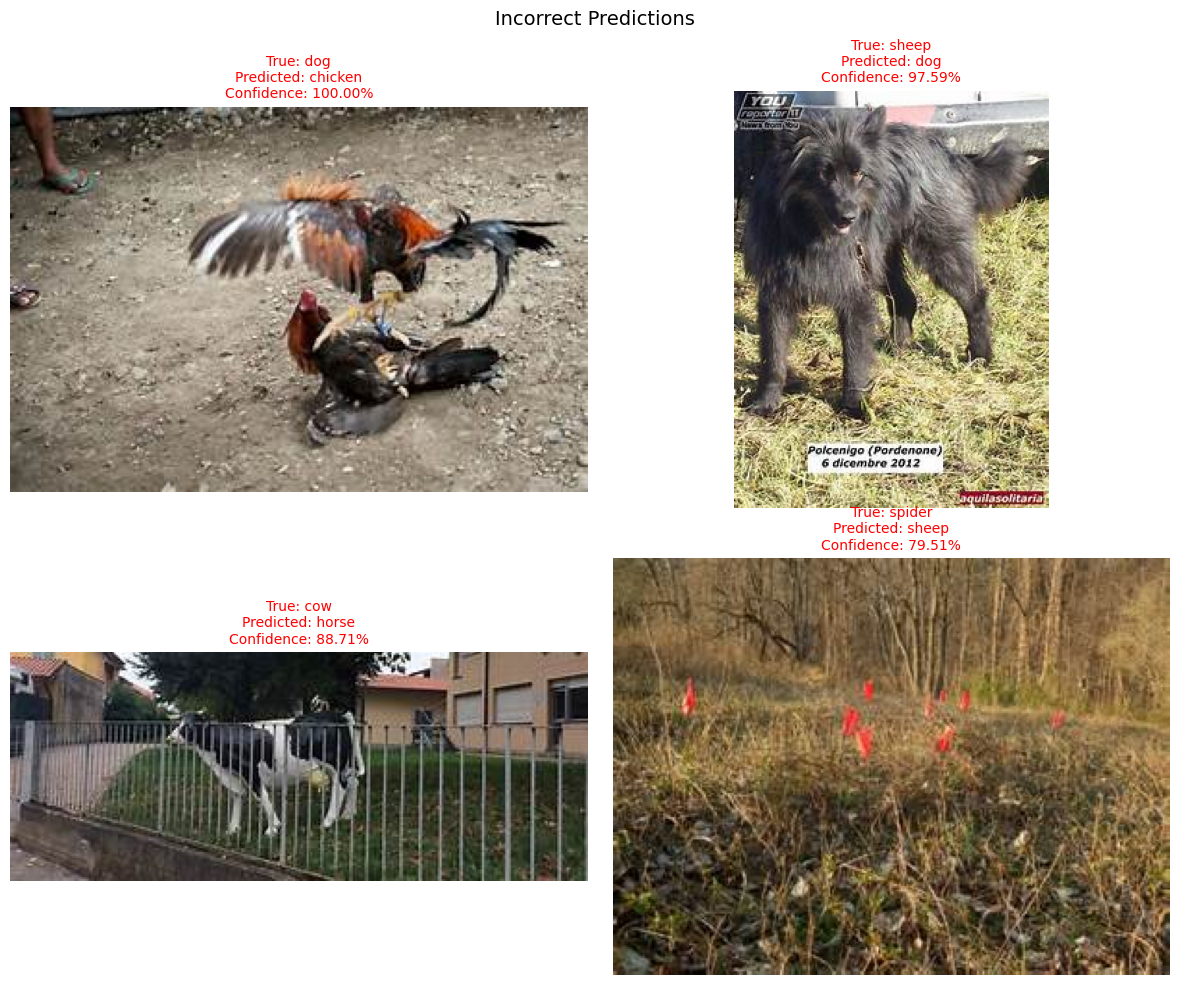


Average confidence for incorrect predictions: 69.24%
Total incorrect: 11

Most common misclassifications:
  sheep → dog: 3 times
  spider → sheep: 1 times
  dog → cow: 1 times
  cow → horse: 1 times
  horse → cow: 1 times


In [11]:
# Show examples of incorrect predictions
if os.path.exists(MODEL_PATH) and 'predictions_details' in locals():
    print("\nExamples of INCORRECT predictions:")
    print("=" * 70)
    
    # Get incorrect predictions
    incorrect_preds = [p for p in predictions_details if not p['correct']]
    
    if len(incorrect_preds) > 0:
        # Sort by confidence (even wrong predictions can be confident)
        incorrect_preds_sorted = sorted(incorrect_preds, key=lambda x: x['confidence'], reverse=True)
        
        # Show up to 4 examples
        num_examples = min(4, len(incorrect_preds))
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for idx in range(num_examples):
            pred = incorrect_preds_sorted[idx]
            
            img = Image.open(pred['path'])
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(
                f"True: {pred['true']}\nPredicted: {pred['pred']}\nConfidence: {pred['confidence']:.2%}",
                fontsize=10,
                color='red'
            )
        
        # Hide unused subplots
        for idx in range(num_examples, 4):
            axes[idx].axis('off')
        
        plt.suptitle("Incorrect Predictions", fontsize=14, y=0.98)
        plt.tight_layout()
        plt.show()
        
        # Print stats
        avg_conf_incorrect = sum(p['confidence'] for p in incorrect_preds) / len(incorrect_preds)
        print(f"\nAverage confidence for incorrect predictions: {avg_conf_incorrect:.2%}")
        print(f"Total incorrect: {len(incorrect_preds)}")
        
        # Show most common misclassifications
        print("\nMost common misclassifications:")
        from collections import Counter
        misclass_pairs = [(p['true'], p['pred']) for p in incorrect_preds]
        common_errors = Counter(misclass_pairs).most_common(5)
        for (true_label, pred_label), count in common_errors:
            print(f"  {true_label} → {pred_label}: {count} times")
    else:
        print("\nNo incorrect predictions found! Perfect accuracy!")
else:
    print("Run evaluation first")

### 4.4. Per-Class Performance Analysis

Per-Class Performance Analysis:

Class           Accuracy     Count    Avg Confidence 
----------------------------------------------------------------------
butterfly       100.00%       32       99.94%
cat             100.00%       24       97.32%
chicken         98.18%       55       99.07%
cow             97.06%       34       92.97%
dog             96.19%       105      97.17%
elephant        100.00%       39       99.96%
horse           98.00%       50       98.13%
sheep           92.50%       40       94.68%
spider          98.91%       92       97.93%
squirrel        100.00%       29       97.96%


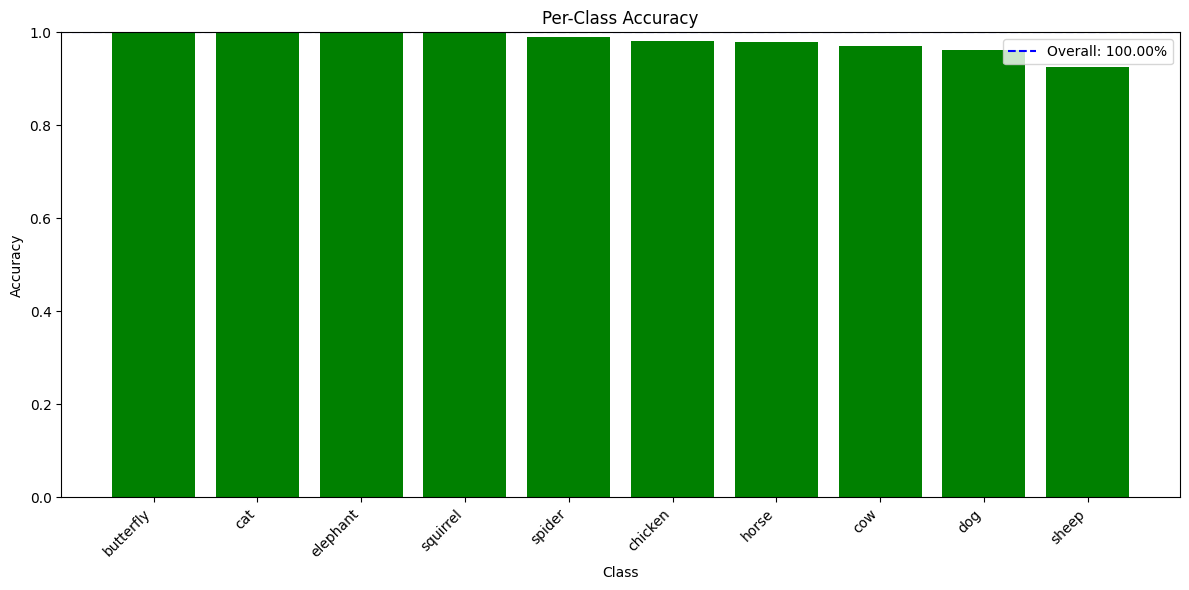


Best performing class: butterfly (100.00%)
Worst performing class: sheep (92.50%)


In [25]:
# Analyze performance per class
if os.path.exists(MODEL_PATH) and 'predictions_details' in locals():
    print("Per-Class Performance Analysis:")
    print("=" * 70)
    
    # Calculate per-class metrics
    from collections import defaultdict
    class_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'confidences': []})
    
    for pred in predictions_details:
        class_name = pred['true']
        class_stats[class_name]['total'] += 1
        class_stats[class_name]['confidences'].append(pred['confidence'])
        if pred['correct']:
            class_stats[class_name]['correct'] += 1
    
    # Create performance table
    print(f"\n{'Class':<15} {'Accuracy':<12} {'Count':<8} {'Avg Confidence':<15}")
    print("-" * 70)
    
    accuracies = []
    for class_name in sorted(class_stats.keys()):
        stats = class_stats[class_name]
        accuracy = stats['correct'] / stats['total'] if stats['total'] > 0 else 0
        avg_conf = sum(stats['confidences']) / len(stats['confidences']) if stats['confidences'] else 0
        accuracies.append((class_name, accuracy))
        
        print(f"{class_name:<15} {accuracy:>6.2%}       {stats['total']:<8} {avg_conf:>6.2%}")
    
    # Visualize per-class accuracy
    accuracies_sorted = sorted(accuracies, key=lambda x: x[1], reverse=True)
    classes, accs = zip(*accuracies_sorted)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(classes, accs, color=['green' if a > 0.9 else 'orange' if a > 0.7 else 'red' for a in accs])
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.title('Per-Class Accuracy')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.axhline(y=accuracy, color='blue', linestyle='--', label=f'Overall: {accuracy:.2%}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Identify best and worst classes
    best_class, best_acc = accuracies_sorted[0]
    worst_class, worst_acc = accuracies_sorted[-1]
    
    print(f"\nBest performing class: {best_class} ({best_acc:.2%})")
    print(f"Worst performing class: {worst_class} ({worst_acc:.2%})")
else:
    print("Run evaluation first")

## 5. Test NER Model

In [4]:
# Load NER model
NER_MODEL_PATH = "../ner/model"

if os.path.exists(NER_MODEL_PATH):
    ner_tokenizer, ner_model = load_ner_model(NER_MODEL_PATH)
    print("NER model loaded successfully")
else:
    print(f"NER model not found at {NER_MODEL_PATH}")
    print("Please train the NER model first")
    

NER model loaded successfully


### 5.1. Basic NER Test Cases

In [34]:
# Test NER extraction
ner_test_cases = [
    "I see a dog in the park",
    "The cat is sleeping",
    "There's a beautiful butterfly",
    "Look at that elephant!",
    "The horse is running fast",
    "This is not a cow",
    "No spider here"
]

if os.path.exists(NER_MODEL_PATH):
    print("NER Extraction Results:")
    print("-" * 60)
    
    for text in ner_test_cases:
        animals = predict_entities(text, ner_tokenizer, ner_model)
        animal_str = animals[0] if animals else "None"
        print(f"Text: {text:40s} | Animal: {animal_str}")
else:
    print("NER model not available")

NER Extraction Results:
------------------------------------------------------------
Text: I see a dog in the park                  | Animal: dog
Text: The cat is sleeping                      | Animal: cat
Text: There's a beautiful butterfly            | Animal: butterfly
Text: Look at that elephant!                   | Animal: elephant
Text: The horse is running fast                | Animal: horse
Text: This is not a cow                        | Animal: cow
Text: No spider here                           | Animal: spider


## 6. Complete Pipeline Test

### 6.1. Positive Cases (Text matches image)

In [12]:
# Import pipeline function
sys.path.insert(0, '../pipeline')
from pipeline import check_statement, extract_animal_from_text, classify_image

In [6]:

if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    
    
    print("Testing positive cases (statement matches image):")
    print("=" * 70)
    
    positive_cases = [
        ("I see a dog", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"),
        ("There is a cat", "../raw-img/gatto/OIP-BH0moeUqbYBKz5ULFrXKMwHaFj.jpeg"),
        ("Look at the horse", "../raw-img/cavallo/OIP-00EYvyJjYIa6MFGRrp2dMAHaE8.jpeg")
    ]
    
    for text, img_path in positive_cases:
        if os.path.exists(img_path):
            print(f"\nText: '{text}'")
            print(f"Image: {os.path.basename(img_path)}")
            result = check_statement(text, img_path)
            print(f"Expected: True | Actual: {result}")
            print("-" * 70)
else:
    print("Models not available for pipeline testing")

Testing positive cases (statement matches image):

Text: 'I see a dog'
Image: OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Text animal: dog
Image animal: dog
Negation: False
Result: True
Expected: True | Actual: True
----------------------------------------------------------------------


### 6.2. Negative Cases (Text doesn't match image)

In [39]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Testing negative cases (statement doesn't match image):")
    print("=" * 70)
    
    negative_cases = [
        ("I see a cat", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"),
        ("There is a dog", "../raw-img/gatto/OIP-BH0moeUqbYBKz5ULFrXKMwHaFj.jpeg"),
        ("Look at the butterfly", "../raw-img/cavallo/OIP-00EYvyJjYIa6MFGRrp2dMAHaE8.jpeg")
    ]
    
    for text, img_path in negative_cases:
        if os.path.exists(img_path):
            print(f"\nText: '{text}'")
            print(f"Image: {os.path.basename(img_path)}")
            result = check_statement(text, img_path)
            print(f"Expected: False | Actual: {result}")
            print("-" * 70)
else:
    print("Models not available for pipeline testing")

Testing negative cases (statement doesn't match image):

Text: 'I see a cat'
Image: OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Text animal: cat
Image animal: dog
Negation: False
Result: False
Expected: False | Actual: False
----------------------------------------------------------------------


### 6.3. Negation Handling

In [40]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Testing negation handling:")
    print("=" * 70)
    
    negation_cases = [
        # Negation with different animal (should be True)
        ("This is not a cat", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", True),
        ("It isn't a dog", "../raw-img/gatto/OIP-BH0moeUqbYBKz5ULFrXKMwHaFj.jpeg", True),
        # Negation with same animal (should be False)
        ("This is not a dog", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", False),
        ("It isn't a cat", "../raw-img/gatto/OIP-BH0moeUqbYBKz5ULFrXKMwHaFj.jpeg", False)
    ]
    
    for text, img_path, expected in negation_cases:
        if os.path.exists(img_path):
            print(f"\nText: '{text}'")
            print(f"Image: {os.path.basename(img_path)}")
            result = check_statement(text, img_path)
            print(f"Expected: {expected} | Actual: {result}")
            status = "Pass" if result == expected else "Fail"
            print(f"Status: {status}")
            print("-" * 70)
else:
    print("Models not available for pipeline testing")

Testing negation handling:

Text: 'This is not a cat'
Image: OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Text animal: cat
Image animal: dog
Negation: True
Result: True
Expected: True | Actual: True
Status: Pass
----------------------------------------------------------------------

Text: 'This is not a dog'
Image: OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Text animal: dog
Image animal: dog
Negation: True
Result: False
Expected: False | Actual: False
Status: Pass
----------------------------------------------------------------------


### 6.4. Complex Negation Patterns (Training Templates)

Testing non-standard negation formats from NER training data

In [7]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Testing complex negation patterns from training templates:")
    print("=" * 70)
    
    # Test cases using actual templates from NER training
    complex_negation_cases = [
        # Template: "This image lacks a {animal}"
        ("This image lacks a dog", "../raw-img/gatto/1.jpeg", True, "lacks"),
        ("This image lacks a cat", "../raw-img/gatto/2.jpeg", False, "lacks"),
        
        # Template: "This is not what I would call a {animal}"
        ("This is not what I would call a dog", "../raw-img/gatto/3.jpeg", True, "not what I would call"),
        ("This is not what I would call a cat", "../raw-img/gatto/5.jpeg", False, "not what I would call"),
        
        # Template: "I don't see a {animal} here"
        ("I don't see a dog here", "../raw-img/gatto/6.jpeg", True, "don't see"),
        ("I don't see a cat here", "../raw-img/gatto/7.jpeg", False, "don't see"),
        
        # Template: "This is definitely not a {animal}"
        ("This is definitely not a horse", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", True, "definitely not"),
        ("This is definitely not a dog", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", False, "definitely not"),
        
        # Template: "This picture doesn't contain a {animal}"
        ("This picture doesn't contain a butterfly", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", True, "doesn't contain"),
        ("This picture doesn't contain a dog", "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg", False, "doesn't contain"),
        
        # Template: "I am sure this is not a {animal}"
        ("I am sure this is not a elephant", "../raw-img/gatto/9.jpeg", True, "sure this is not"),
        ("I am sure this is not a cat", "../raw-img/gatto/10.jpeg", False, "sure this is not"),
    ]
    
    passed = 0
    failed = 0
    
    for text, img_path, expected, pattern_type in complex_negation_cases:
        if os.path.exists(img_path):
            print(f"\nPattern: '{pattern_type}'")
            print(f"Text: '{text}'")
            print(f"Image: {os.path.basename(img_path)}")
            
            # Extract animal to verify NER works
            animal_extracted = extract_animal_from_text(text)
            print(f"Extracted animal: {animal_extracted}")
            
            result = check_statement(text, img_path)
            print(f"Expected: {expected} | Actual: {result}")
            
            if result == expected:
                status = "✓ Pass"
                passed += 1
            else:
                status = "✗ Fail"
                failed += 1
            
            print(f"Status: {status}")
            print("-" * 70)
    
    print(f"\nSummary:")
    print(f"Passed: {passed}/{len(complex_negation_cases)}")
    print(f"Failed: {failed}/{len(complex_negation_cases)}")
    print(f"Success Rate: {passed/len(complex_negation_cases)*100:.1f}%")
    
else:
    print("Models not available for pipeline testing")

Testing complex negation patterns from training templates:

Pattern: 'lacks'
Text: 'This image lacks a dog'
Image: 1.jpeg
Extracted animal: dog
Text animal: dog
Image animal: cat
Negation: True
Result: True
Expected: True | Actual: True
Status: ✓ Pass
----------------------------------------------------------------------

Pattern: 'lacks'
Text: 'This image lacks a cat'
Image: 2.jpeg
Extracted animal: cat
Text animal: cat
Image animal: cat
Negation: True
Result: False
Expected: False | Actual: False
Status: ✓ Pass
----------------------------------------------------------------------

Pattern: 'not what I would call'
Text: 'This is not what I would call a dog'
Image: 3.jpeg
Extracted animal: dog
Text animal: dog
Image animal: cat
Negation: True
Result: True
Expected: True | Actual: True
Status: ✓ Pass
----------------------------------------------------------------------

Pattern: 'not what I would call'
Text: 'This is not what I would call a cat'
Image: 5.jpeg
Extracted animal: cat
Tex

## 7. Edge Cases

### 7.1. No Animal Mentioned in Text

In [41]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Edge Case: No animal in text")
    print("=" * 70)
    
    no_animal_cases = [
        "This is a beautiful day",
        "I love nature",
        "The sky is blue"
    ]
    
    img_path = "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"
    
    if os.path.exists(img_path):
        for text in no_animal_cases:
            print(f"\nText: '{text}'")
            result = check_statement(text, img_path)
            print(f"Result: {result} (None expected)")
            print("-" * 70)
else:
    print("Models not available")

Edge Case: No animal in text

Text: 'This is a beautiful day'
No animal found in text.
Result: None (None expected)
----------------------------------------------------------------------

Text: 'I love nature'
No animal found in text.
Result: None (None expected)
----------------------------------------------------------------------

Text: 'The sky is blue'
No animal found in text.
Result: None (None expected)
----------------------------------------------------------------------


### 7.2. Multiple Animals in Text

In [42]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Edge Case: Multiple animals in text")
    print("=" * 70)
    
    multi_animal_texts = [
        "I see a dog and a cat",
        "The horse is near the cow",
        "Both the spider and the butterfly are beautiful"
    ]
    
    img_path = "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"
    
    if os.path.exists(img_path):
        for text in multi_animal_texts:
            print(f"\nText: '{text}'")
            animal = extract_animal_from_text(text)
            print(f"First animal extracted: {animal}")
            result = check_statement(text, img_path)
            print(f"Result: {result}")
            print("Note: Pipeline uses first detected animal")
            print("-" * 70)
else:
    print("Models not available")

Edge Case: Multiple animals in text

Text: 'I see a dog and a cat'
First animal extracted: dog
Text animal: dog
Image animal: dog
Negation: False
Result: True
Result: True
Note: Pipeline uses first detected animal
----------------------------------------------------------------------

Text: 'The horse is near the cow'
First animal extracted: horse
Text animal: horse
Image animal: dog
Negation: False
Result: False
Result: False
Note: Pipeline uses first detected animal
----------------------------------------------------------------------

Text: 'Both the spider and the butterfly are beautiful'
First animal extracted: spider
Text animal: spider
Image animal: dog
Negation: False
Result: False
Result: False
Note: Pipeline uses first detected animal
----------------------------------------------------------------------


### 7.4. Case Sensitivity and Variations

In [43]:
if os.path.exists(MODEL_PATH) and os.path.exists(NER_MODEL_PATH):
    print("Edge Case: Text variations and case sensitivity")
    print("=" * 70)
    
    text_variations = [
        "I see a DOG",
        "I see a Dog",
        "I see a dog",
        "There's a big dog here",
        "A small dog is running"
    ]
    
    img_path = "../raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg"
    
    if os.path.exists(img_path):
        for text in text_variations:
            print(f"\nText: '{text}'")
            animal = extract_animal_from_text(text)
            print(f"Extracted animal: {animal}")
            result = check_statement(text, img_path)
            print(f"Result: {result}")
            print("-" * 70)
else:
    print("Models not available")

Edge Case: Text variations and case sensitivity

Text: 'I see a DOG'
Extracted animal: None
No animal found in text.
Result: None
----------------------------------------------------------------------

Text: 'I see a Dog'
Extracted animal: Dog
Text animal: Dog
Image animal: dog
Negation: False
Result: False
Result: False
----------------------------------------------------------------------

Text: 'I see a dog'
Extracted animal: dog
Text animal: dog
Image animal: dog
Negation: False
Result: True
Result: True
----------------------------------------------------------------------

Text: 'There's a big dog here'
Extracted animal: dog
Text animal: dog
Image animal: dog
Negation: False
Result: True
Result: True
----------------------------------------------------------------------

Text: 'A small dog is running'
Extracted animal: dog
Text animal: dog
Image animal: dog
Negation: False
Result: True
Result: True
----------------------------------------------------------------------
